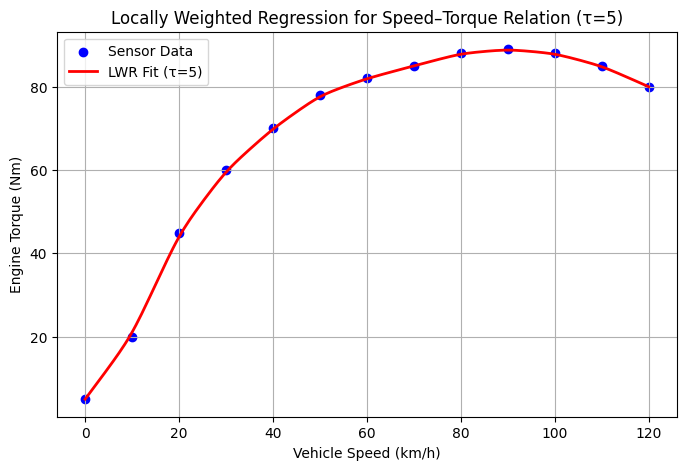

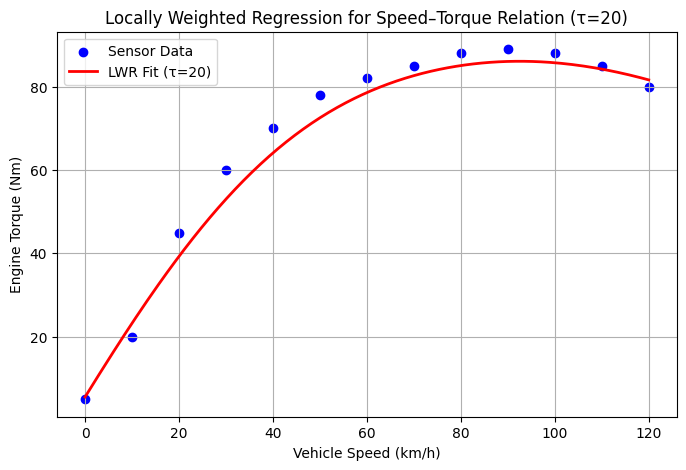

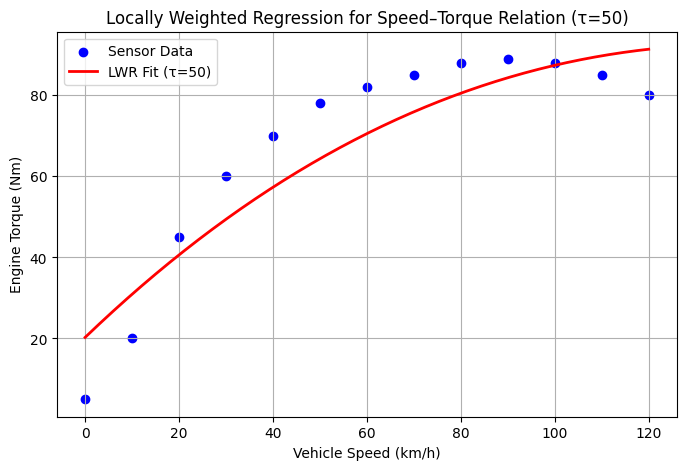

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load dataset
# ---------------------------
data = pd.read_csv("vehicle_speed_torque.csv")
X = data["Speed_kmph"].values.reshape(-1, 1)
y = data["Torque_Nm"].values

# ---------------------------
# Step 2: Define LWR function
# ---------------------------
def locally_weighted_regression(X, y, x_query, tau=20):
    m = X.shape[0]
    y_pred = np.zeros(x_query.shape[0])

    for i, xq in enumerate(x_query):
        # Gaussian weights based on distance
        w = np.exp(-np.sum((X - xq)**2, axis=1) / (2 * tau**2))
        W = np.diag(w)

        # Add bias term
        X_design = np.hstack((np.ones((m, 1)), X))

        # Weighted least squares solution
        theta = np.linalg.pinv(X_design.T @ W @ X_design) @ (X_design.T @ W @ y)

        # Predict output for the query point (fixed line)
        y_pred[i] = np.array([1, xq.item()]) @ theta

    return y_pred

# ---------------------------
# Step 3: Fit and visualize
# ---------------------------
X_query = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

for tau in [5, 20, 50]:
    y_pred = locally_weighted_regression(X, y, X_query, tau)
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color="blue", label="Sensor Data")
    plt.plot(X_query, y_pred, color="red", linewidth=2, label=f"LWR Fit (τ={tau})")
    plt.xlabel("Vehicle Speed (km/h)")
    plt.ylabel("Engine Torque (Nm)")
    plt.title(f"Locally Weighted Regression for Speed–Torque Relation (τ={tau})")
    plt.legend()
    plt.grid(True)
    plt.show()
